In [ ]:
from sklearn.datasets import fetch_openml

# Load Adult Census Income dataset
adult = fetch_openml('adult', version=2, as_frame=True)

# Store dataset in DataFrame
df = adult.frame

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)


Dataset loaded successfully!
Dataset shape: (48842, 15)


In [3]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [5]:
import pandas as pd

In [6]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)

df[['age', 'age_group']].head()

,age,age_group
0,25,18-25
1,38,36-45
2,28,26-35
3,44,36-45
4,18,18-25


In [7]:
#  Task 1 Create groups for weekly working hours
df['hours_group'] = pd.cut(
    df['hours-per-week'],
    bins=[0, 30, 40, 50, 100],
    labels=['Low', 'Normal', 'High', 'Very High']
)

# Create a flag to show whether a person has capital gain
df['has_capital_gain'] = (df['capital-gain'] > 0).astype(int)

df[['hours-per-week', 'hours_group', 'capital-gain', 'has_capital_gain']].head()

,hours-per-week,hours_group,capital-gain,has_capital_gain
0,40,Normal,0,0
1,50,High,0,0
2,40,Normal,0,0
3,40,Normal,7688,1
4,30,Low,0,0


In [9]:
import numpy as np

In [10]:
# Apply log transformation to reduce the effect of large capital gain values
df['log_capital_gain'] = np.log1p(df['capital-gain'])

# Create a flag for higher education
df['higher_education'] = (df['education-num'] >= 13).astype(int)

df[['capital-gain', 'log_capital_gain', 'education-num', 'higher_education']].head()

,capital-gain,log_capital_gain,education-num,higher_education
0,0,0.000000,7,0
1,0,0.000000,9,0
2,0,0.000000,12,0
3,7688,8.947546,10,0
4,0,0.000000,10,0


In [11]:
# Create an interaction feature between education and working hours
df['education_hours_interaction'] = (
    df['education-num'] * df['hours-per-week']
)

df[['education-num', 'hours-per-week', 'education_hours_interaction']].head()

,education-num,hours-per-week,education_hours_interaction
0,7,40,280
1,9,50,450
2,12,40,480
3,10,40,400
4,10,30,300


In [12]:
# Convert the target column into numeric values
y = df['class'].map({'<=50K': 0, '>50K': 1})

print(y.head())

0    0
1    0
2    1
3    1
4    0
Name: class, dtype: category
Categories (2, int64): [0, 1]


In [13]:
from sklearn.feature_selection import mutual_info_classif

# Convert categorical feature groups into numeric codes
age_group_num = df['age_group'].cat.codes
hours_group_num = df['hours_group'].cat.codes

# Calculate mutual information scores
age_score = mutual_info_classif(age_group_num.to_numpy().reshape(-1, 1), y, random_state=42)[0]
hours_score = mutual_info_classif(hours_group_num.to_numpy().reshape(-1, 1), y, random_state=42)[0]

print("age_group:", age_score)
print("hours_group:", hours_score)

age_group: 0.062400640341506275
hours_group: 0.04004394800182287


In [14]:
# Calculate mutual information scores for the next two features
gain_score = mutual_info_classif(
    df[['has_capital_gain']], y, random_state=42
)[0]

log_gain_score = mutual_info_classif(
    df[['log_capital_gain']], y, random_state=42
)[0]

print("has_capital_gain:", gain_score)
print("log_capital_gain:", log_gain_score)

has_capital_gain: 0.0290612633013434
log_capital_gain: 0.08300637690940715


In [15]:
# Calculate mutual information scores for the last two features
education_score = mutual_info_classif(
    df[['higher_education']], y, random_state=42
)[0]

interaction_score = mutual_info_classif(
    df[['education_hours_interaction']], y, random_state=42
)[0]

print("higher_education:", education_score)
print("education_hours_interaction:", interaction_score)

higher_education: 0.0483122576636823
education_hours_interaction: 0.0814804856900826


In [16]:
#  Task 1 Create a feature dictionary with justification and predictive signal
feature_dictionary = {
    'age_group': {
        'type': 'Categorical',
        'creation_rule': 'Group age into different age ranges',
        'justification': 'Age groups may capture different income patterns across age ranges',
        'predictive_signal': 0.0624
    },
    'hours_group': {
        'type': 'Categorical',
        'creation_rule': 'Group weekly working hours into bins',
        'justification': 'Different working-hour levels may be related to income',
        'predictive_signal': 0.0400
    },
    'has_capital_gain': {
        'type': 'Binary',
        'creation_rule': '1 if capital-gain is greater than 0, otherwise 0',
        'justification': 'Having any capital gain may indicate higher earning or investment activity',
        'predictive_signal': 0.0291
    },
    'log_capital_gain': {
        'type': 'Numeric',
        'creation_rule': 'Apply log transformation to capital-gain',
        'justification': 'Log transformation reduces the effect of very large capital-gain values',
        'predictive_signal': 0.0830
    },
    'higher_education': {
        'type': 'Binary',
        'creation_rule': '1 if education-num is 13 or higher, otherwise 0',
        'justification': 'Higher education may be associated with higher income',
        'predictive_signal': 0.0483
    },
    'education_hours_interaction': {
        'type': 'Numeric',
        'creation_rule': 'Multiply education-num by hours-per-week',
        'justification': 'The combination of education and working hours may provide additional income-related information',
        'predictive_signal': 0.0815
    }
}

print(feature_dictionary)

{'age_group': {'type': 'Categorical', 'creation_rule': 'Group age into different age ranges', 'justification': 'Age groups may capture different income patterns across age ranges', 'predictive_signal': 0.0624}, 'hours_group': {'type': 'Categorical', 'creation_rule': 'Group weekly working hours into bins', 'justification': 'Different working-hour levels may be related to income', 'predictive_signal': 0.04}, 'has_capital_gain': {'type': 'Binary', 'creation_rule': '1 if capital-gain is greater than 0, otherwise 0', 'justification': 'Having any capital gain may indicate higher earning or investment activity', 'predictive_signal': 0.0291}, 'log_capital_gain': {'type': 'Numeric', 'creation_rule': 'Apply log transformation to capital-gain', 'justification': 'Log transformation reduces the effect of very large capital-gain values', 'predictive_signal': 0.083}, 'higher_education': {'type': 'Binary', 'creation_rule': '1 if education-num is 13 or higher, otherwise 0', 'justification': 'Higher edu

Feature Justifications

- **age_group:** Age groups may capture different income patterns across different age ranges.
- **hours_group:** Different working-hour levels may be related to income.
- **has_capital_gain:** Having capital gain may indicate investment activity and may be related to higher income.
- **log_capital_gain:** Log transformation reduces the effect of very large capital-gain values.
- **higher_education:** Higher education may be associated with higher income.
- **education_hours_interaction:** The combination of education and working hours may provide additional information about income.

In [19]:
# Calculate mutual information scores for the next two features
gain_score = mutual_info_classif(
    df[['has_capital_gain']], y, random_state=42
)[0]

log_gain_score = mutual_info_classif(
    df[['log_capital_gain']], y, random_state=42
)[0]

print("has_capital_gain:", gain_score)
print("log_capital_gain:", log_gain_score)

has_capital_gain: 0.0290612633013434
log_capital_gain: 0.08300637690940715


In [ ]:
from sklearn.preprocessing import FunctionTransformer

# Create a function to generate engineered features
def create_features(X):
    X = X.copy()

    # Create age groups
    X['age_group'] = pd.cut(
        X['age'],
        bins=[0, 25, 35, 45, 55, 100],
        labels=['18-25', '26-35', '36-45', '46-55', '56+']
    )

    # Create working hours groups
    X['hours_group'] = pd.cut(
        X['hours-per-week'],
        bins=[0, 30, 40, 50, 100],
        labels=['Low', 'Normal', 'High', 'Very High']
    )
  # Create the remaining engineered features
    X['has_capital_gain'] = (X['capital-gain'] > 0).astype(int)
    X['log_capital_gain'] = np.log1p(X['capital-gain'])
    X['higher_education'] = (X['education-num'] >= 13).astype(int)
    X['education_hours_interaction'] = X['education-num'] * X['hours-per-week']
    return X

In [22]:
# Test the feature engineering function
new_df = create_features(df)

new_df[['age_group', 'hours_group', 'has_capital_gain',
        'log_capital_gain', 'higher_education',
        'education_hours_interaction']].head()

,age_group,hours_group,has_capital_gain,log_capital_gain,higher_education,education_hours_interaction
0,18-25,Normal,0,0.000000,0,280
1,36-45,High,0,0.000000,0,450
2,26-35,Normal,0,0.000000,0,480
3,36-45,Normal,1,8.947546,0,400
4,18-25,Low,0,0.000000,0,300


In [23]:
# Select numerical and categorical columns
numeric_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'has_capital_gain',
    'log_capital_gain',
    'higher_education',
    'education_hours_interaction'
]

categorical_features = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'age_group',
    'hours_group'
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 10
Categorical features: 10


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocess numerical features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocess categorical features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both preprocessing steps
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [25]:
# Create a feature engineering transformer
feature_engineering = FunctionTransformer(create_features)

# Combine feature engineering with preprocessing
full_preprocessor = Pipeline([
    ('feature_engineering', feature_engineering),
    ('preprocessing', preprocessor)
])

print("Full preprocessing pipeline created successfully!")

Full preprocessing pipeline created successfully!


In [26]:
# Separate features and target
X = df.drop('class', axis=1)
y = df['class'].map({'<=50K': 0, '>50K': 1})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (48842, 20)
Target shape: (48842,)


In [27]:
# Apply feature engineering and preprocessing
X_processed = full_preprocessor.fit_transform(X)

print("Preprocessing completed successfully!")
print("Processed data shape:", X_processed.shape)

Preprocessing completed successfully!
Processed data shape: (48842, 118)


In [28]:
from sklearn.model_selection import StratifiedKFold

# Create 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold cross-validation created successfully!")

5-fold cross-validation created successfully!


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Create the three machine learning models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

print("Three models created successfully!")

Three models created successfully!


In [30]:
# Create a complete pipeline for each model
model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline([
        ('preprocessing', full_preprocessor),
        ('model', model)
    ])

print("Model pipelines created successfully!")

Model pipelines created successfully!


In [31]:
from sklearn.model_selection import cross_validate

# Define the evaluation metrics
scoring = {
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Store cross-validation results
cv_results = {}

for name, pipeline in model_pipelines.items():
    results = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring
    )
    
    cv_results[name] = results

print("Cross-validation completed successfully!")

Cross-validation completed successfully!


In [33]:
# Create a summary of cross-validation results
results_summary = []

for name, results in cv_results.items():
    results_summary.append({
        'Model': name,
        'F1 Mean': results['test_f1'].mean(),
        'F1 Std': results['test_f1'].std(),
        'ROC AUC Mean': results['test_roc_auc'].mean(),
        'ROC AUC Std': results['test_roc_auc'].std()
    })

results_summary_df = pd.DataFrame(results_summary)

results_summary_df

,Model,F1 Mean,F1 Std,ROC AUC Mean,ROC AUC Std
0,Logistic Regression,0.673159,0.004241,0.912907,0.002242


In [34]:
# Check which models have cross-validation results
print(cv_results.keys())

dict_keys(['Logistic Regression'])


In [35]:
# Test Random Forest and show any error clearly
results_rf = cross_validate(
    model_pipelines['Random Forest'],
    X,
    y,
    cv=cv,
    scoring=scoring,
    error_score='raise'
)

print("Random Forest completed successfully!")

Random Forest completed successfully!


In [36]:
# Save Random Forest results
cv_results['Random Forest'] = results_rf

print("Random Forest result saved!")

Random Forest result saved!


In [37]:
# Test Gradient Boosting and show any error clearly
results_gb = cross_validate(
    model_pipelines['Gradient Boosting'],
    X,
    y,
    cv=cv,
    scoring=scoring,
    error_score='raise'
)

print("Gradient Boosting completed successfully!")

Gradient Boosting completed successfully!


In [38]:
# Save Gradient Boosting results
cv_results['Gradient Boosting'] = results_gb

print("Gradient Boosting result saved!") 

Gradient Boosting result saved!


In [39]:
# Create final model comparison table
results_summary = []

for name, results in cv_results.items():
    results_summary.append({
        'Model': name,
        'F1 Mean': results['test_f1'].mean(),
        'F1 Std': results['test_f1'].std(),
        'ROC AUC Mean': results['test_roc_auc'].mean(),
        'ROC AUC Std': results['test_roc_auc'].std()
    })

results_summary_df = pd.DataFrame(results_summary)

results_summary_df

,Model,F1 Mean,F1 Std,ROC AUC Mean,ROC AUC Std
0,Logistic Regression,0.673159,0.004241,0.912907,0.002242
1,Random Forest,0.670098,0.006339,0.901015,0.002116
2,Gradient Boosting,0.684439,0.007394,0.920340,0.001822


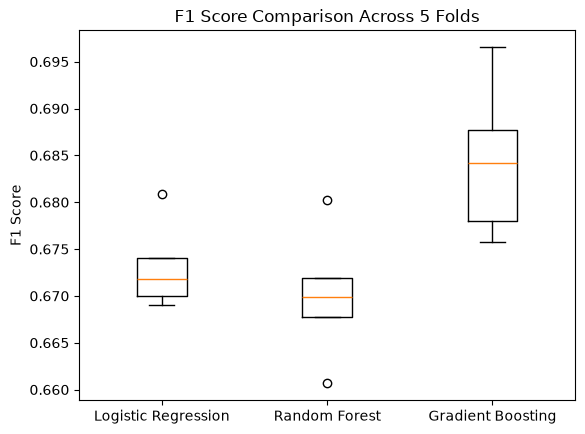

In [41]:
import matplotlib.pyplot as plt

# Collect F1 scores from all models
f1_scores = [
    cv_results['Logistic Regression']['test_f1'],
    cv_results['Random Forest']['test_f1'],
    cv_results['Gradient Boosting']['test_f1']
]

# Create boxplot
plt.boxplot(
    f1_scores,
    tick_labels=['Logistic Regression', 'Random Forest', 'Gradient Boosting']
)

plt.ylabel('F1 Score')
plt.title('F1 Score Comparison Across 5 Folds')
plt.show()

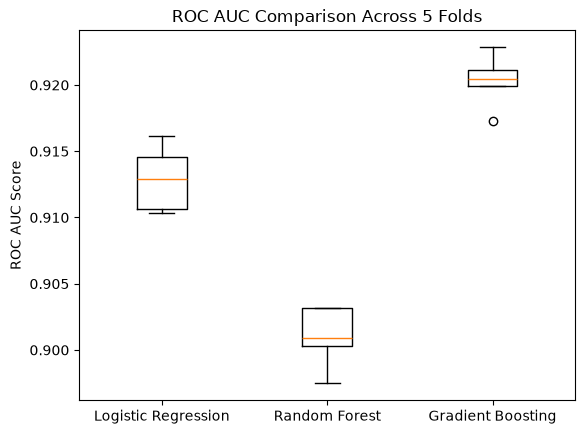

In [42]:
# Collect ROC-AUC scores from all models
roc_auc_scores = [
    cv_results['Logistic Regression']['test_roc_auc'],
    cv_results['Random Forest']['test_roc_auc'],
    cv_results['Gradient Boosting']['test_roc_auc']
]

# Create ROC-AUC boxplot
plt.boxplot(
    roc_auc_scores,
    tick_labels=['Logistic Regression', 'Random Forest', 'Gradient Boosting']
)

plt.ylabel('ROC AUC Score')
plt.title('ROC AUC Comparison Across 5 Folds')
plt.show()

In [43]:
## Task 4: Paired Statistical Test and Feature Importance

from scipy.stats import ttest_rel

# Get F1 scores of the top two models
gb_scores = cv_results['Gradient Boosting']['test_f1']
lr_scores = cv_results['Logistic Regression']['test_f1']

# Perform paired t-test to compare the two models
t_stat, p_value = ttest_rel(gb_scores, lr_scores)

# Display the statistical test results
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 5.762733033177827
P-value: 0.004499053221456763


In [45]:
# Fit the best tree-based model
best_tree_model = model_pipelines['Gradient Boosting']

best_tree_model.fit(X, y)

print("Gradient Boosting model fitted successfully!")

Gradient Boosting model fitted successfully!


In [46]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get feature importance values from Gradient Boosting
importances = best_tree_model.named_steps['model'].feature_importances_

# Create a DataFrame for feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort features from most important to least important
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display the top 20 important features
importance_df.head(20)

,Feature,Importance
36,cat__marital-status_Married-civ-spouse,0.390317
9,num__education_hours_interaction,0.128813
7,num__log_capital_gain,0.116550
2,num__education-num,0.110536
3,num__capital-gain,0.083459
4,num__capital-loss,0.058051
0,num__age,0.054326
44,cat__occupation_Exec-managerial,0.013978
48,cat__occupation_Other-service,0.005284
45,cat__occupation_Farming-fishing,0.005277


In [47]:
# Fit Logistic Regression model
logistic_model = model_pipelines['Logistic Regression']

logistic_model.fit(X, y)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = logistic_model.named_steps['model'].coef_[0]

# Create a DataFrame for coefficients
coefficient_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute coefficient value
coefficient_df['Absolute Coefficient'] = coefficient_df['Coefficient'].abs()

coefficient_df = coefficient_df.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

# Display the top 20 coefficients
coefficient_df.head(20)

,Feature,Coefficient,Absolute Coefficient
7,num__log_capital_gain,5.231740,5.231740
6,num__has_capital_gain,-5.036551,5.036551
3,num__capital-gain,1.961761,1.961761
35,cat__marital-status_Married-AF-spouse,1.464991,1.464991
36,cat__marital-status_Married-civ-spouse,1.464176,1.464176
109,cat__age_group_18-25,-1.443095,1.443095
71,cat__native-country_Columbia,-1.338125,1.338125
88,cat__native-country_Ireland,1.204603,1.204603
49,cat__occupation_Priv-house-serv,-1.116391,1.116391
115,cat__hours_group_Low,-1.089960,1.089960


In [48]:
## Task 5: Feature Selection and Dimensionality Check

# Check the number of features after preprocessing
print("Total features after preprocessing:", X_processed.shape[1])

Total features after preprocessing: 118


In [49]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Select the 20 most informative features
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=20
)

# Select the best features from the preprocessed data
X_selected = selector.fit_transform(X_processed, y)

print("Original features:", X_processed.shape[1])
print("Selected features:", X_selected.shape[1])

c:\Users\Tooba Iqbal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\Tooba Iqbal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\Tooba Iqbal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\Tooba Iqbal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metri

Original features: 118
Selected features: 20


In [50]:
import time
from sklearn.model_selection import cross_validate

# Start measuring training time
start_time = time.time()

# Evaluate Logistic Regression using the selected features
selected_results = cross_validate(
    LogisticRegression(max_iter=1000),
    X_selected,
    y,
    cv=cv,
    scoring=scoring
)

# Calculate total training time
selected_time = time.time() - start_time

print("Selected features CV completed!")
print("Training time:", round(selected_time, 2), "seconds")
print("Mean F1:", selected_results['test_f1'].mean())
print("Mean ROC AUC:", selected_results['test_roc_auc'].mean())

Selected features CV completed!
Training time: 1.83 seconds
Mean F1: 0.6517153667018905
Mean ROC AUC: 0.9045073909487952


In [51]:
# Compare all features with the selected 20 features

comparison = pd.DataFrame({
    'Version': ['All Features', 'Selected 20 Features'],
    'F1 Mean': [
        cv_results['Logistic Regression']['test_f1'].mean(),
        selected_results['test_f1'].mean()
    ],
    'ROC AUC Mean': [
        cv_results['Logistic Regression']['test_roc_auc'].mean(),
        selected_results['test_roc_auc'].mean()
    ],
    'Mean Fit Time (s)': [
        cv_results['Logistic Regression']['fit_time'].mean(),
        selected_results['fit_time'].mean()
    ]
})

comparison

,Version,F1 Mean,ROC AUC Mean,Mean Fit Time (s)
0,All Features,0.673159,0.912907,0.881898
1,Selected 20 Features,0.651715,0.904507,0.345452


Task 5 Conclusion

The SelectKBest feature selection reduced the number of features from 118 to 20 and decreased the training time. However, model performance also decreased, with F1 score dropping from 0.6732 to 0.6517 and ROC AUC dropping from 0.9129 to 0.9045.

Therefore, all 118 features will be retained for tomorrow's hyperparameter tuning because they provide better overall model performance.